### Sección: Análisis Exploratorio de Datos (EDA) en Desarrollo

Esta sección está dedicada a la **exploración iterativa y minería de datos sobre el dataset del Censo de la Provincia de Salta**. El objetivo principal es interrogar la base de datos desde múltiples dimensiones para visibilizar y localizar geográficamente las necesidades estructurales de la población.

Este espacio se encuentra en **constante desarrollo**. A medida que se descubran nuevos patrones, anomalías o variables críticas, se irán incorporando de forma secuencial nuevas consultas y visualizaciones con el fin de transformar datos crudos en un **diagnóstico territorial accionable** para la planificación de mejoras y obras públicas.

In [ ]:
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning)

In [46]:
load_dotenv()

DB_CONFIG = {
    "dbname": os.getenv("POSTGRES_DB"),
    "user": os.getenv("POSTGRES_USER"),
    "password": os.getenv("POSTGRES_PASSWORD"),
    "host": os.getenv("POSTGRES_HOST"),
    "port": os.getenv("POSTGRES_PORT"),
}

DATABASE_URL = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
)

engine = create_engine(DATABASE_URL, pool_pre_ping=True)

In [47]:
query_nbi = """
    SELECT 
        dg.departamento,
        dc.categoria AS condicion_social,
        SUM(fh.cantidad) AS total_hogares
    FROM fact_hogar fh
    JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
    JOIN dim_variables dv ON dc.id_variable = dv.id_variable
    JOIN dim_geografia dg ON fh.codigo = dg.codigo
    WHERE dv.cod_variable = 'HOGAR_NBI_TOT'
    GROUP BY dg.departamento, dc.categoria;
"""

df_raw = pd.read_sql(query_nbi, engine)

df_raw['condicion_social'] = df_raw['condicion_social'].str.lower().map({'sí': 'Insatisfecho', 'no': 'Satisfecho'})

df_raw['total_hogares'] = df_raw['total_hogares'].astype(int)
df_raw['porcentaje'] = (df_raw['total_hogares'] / df_raw.groupby('departamento')['total_hogares'].transform('sum')) * 100
df_raw['porcentaje'] = df_raw['porcentaje'].round(2)

df_raw['p_insatisfecho'] = df_raw['porcentaje'].where(df_raw['condicion_social'] == 'Insatisfecho')

df_raw['orden_depto'] = df_raw.groupby('departamento')['p_insatisfecho'].transform('max')

df_ordenado = df_raw.sort_values(
    by=['orden_depto', 'departamento', 'condicion_social'], 
    ascending=[False, True, False]
)

df_ordenado = df_ordenado.drop(columns=['p_insatisfecho', 'orden_depto']).reset_index(drop=True)

print("Estructura de estratos ordenada por porcentaje de insatisfacción:")
display(df_ordenado)

Estructura de estratos ordenada por porcentaje de insatisfacción:


,departamento,condicion_social,total_hogares,porcentaje
0,Rivadavia,Satisfecho,6654,60.08
1,Rivadavia,Insatisfecho,4421,39.92
2,General Jose de San Martin,Satisfecho,39552,78.40
3,General Jose de San Martin,Insatisfecho,10897,21.60
4,Oran,Satisfecho,35458,80.14
5,Oran,Insatisfecho,8787,19.86
6,Anta,Satisfecho,15524,80.20
7,Anta,Insatisfecho,3833,19.80
8,Guachipas,Satisfecho,902,82.15
9,Guachipas,Insatisfecho,196,17.85


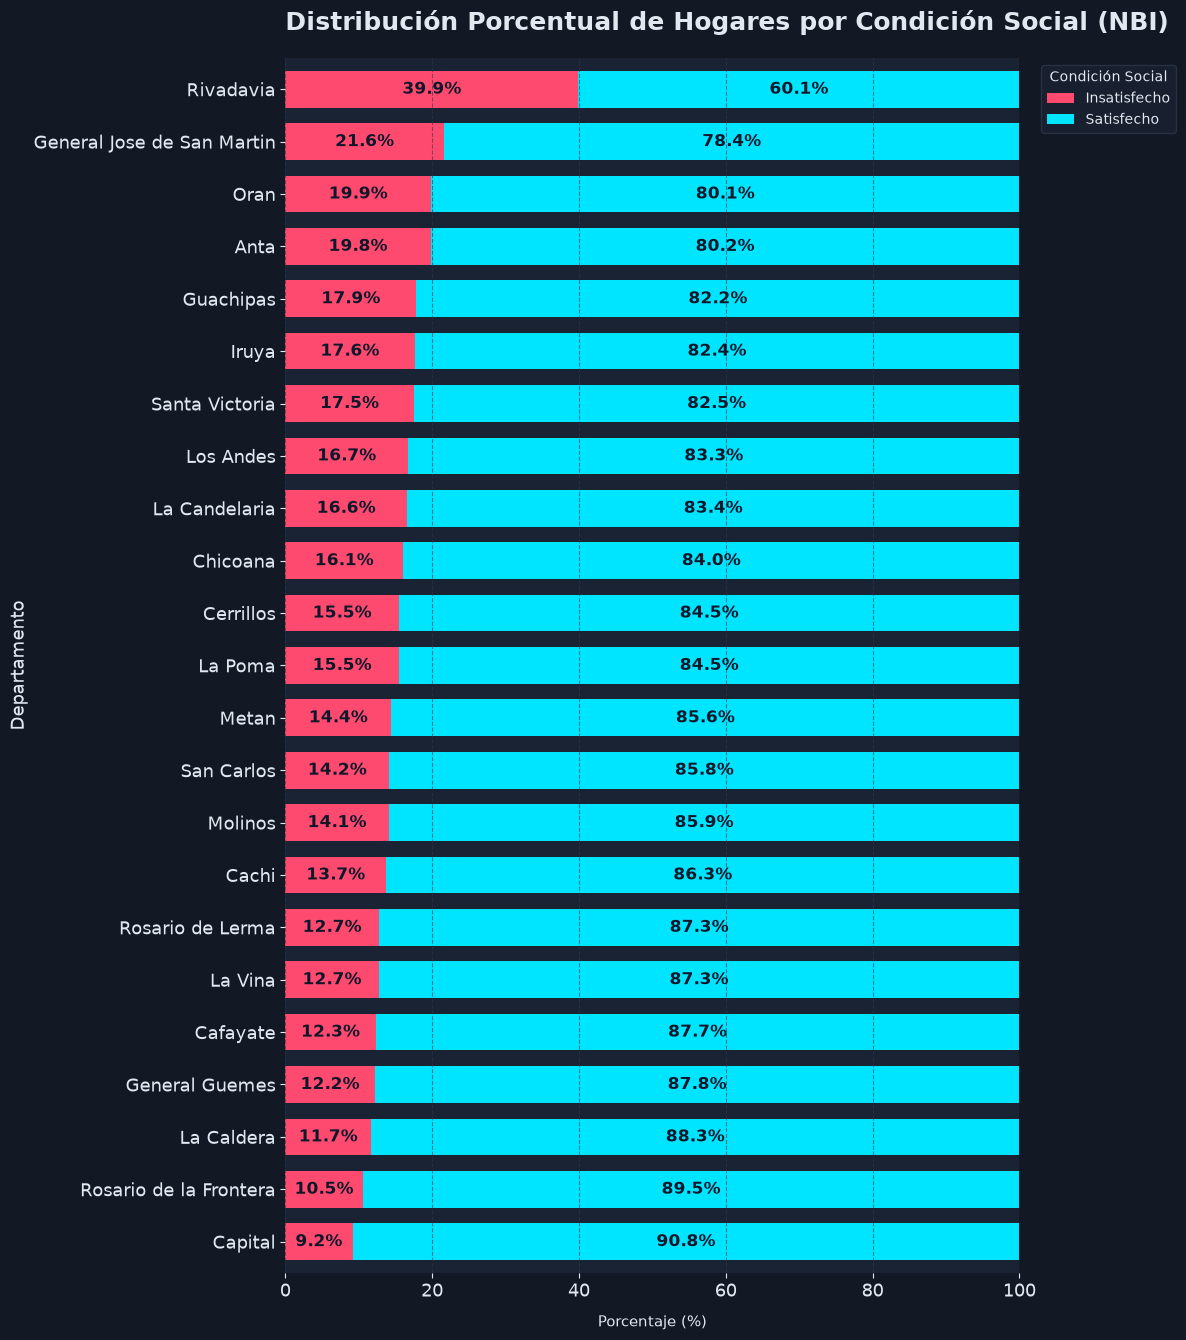

In [48]:
FONDO_OSCURO = '#121824'
FONDO_GRAFICO = '#1a2333'
COLOR_TEXTO = '#E2E8F0'
COLOR_GRILLA = '#2D3748'

df_plot = df_ordenado.pivot(index='departamento', columns='condicion_social', values='porcentaje')
deptos_ordenados = df_ordenado[df_ordenado['condicion_social'] == 'Insatisfecho'].sort_values(by='porcentaje', ascending=True)['departamento']
df_plot = df_plot.loc[deptos_ordenados]

fig, ax = plt.subplots(figsize=(12, len(df_plot) * 0.5 + 2), facecolor=FONDO_OSCURO)
ax.set_facecolor(FONDO_GRAFICO)

colores_premium = ['#FF4A70', '#00E5FF'] 
df_plot[['Insatisfecho', 'Satisfecho']].plot(kind='barh', stacked=True, color=colores_premium, ax=ax, width=0.7)

for p in ax.patches:
    width = p.get_width()
    if width > 5:  
        ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2, 
                f'{width:.1f}%', 
                ha='center', va='center', 
                color='#0F172A', fontweight='bold', fontsize=12.5)

ax.set_title('Distribución Porcentual de Hogares por Condición Social (NBI)', 
             fontsize=18, fontweight='bold', pad=20, loc='left', color=COLOR_TEXTO)
ax.set_xlabel('Porcentaje (%)', fontsize=11, labelpad=10, color=COLOR_TEXTO)
ax.set_ylabel('Departamento', fontsize=13, color=COLOR_TEXTO)
ax.set_xlim(0, 100)

ax.tick_params(axis='x', colors=COLOR_TEXTO, labelsize=13)
ax.tick_params(axis='y', colors=COLOR_TEXTO, labelsize=13)
ax.grid(True, axis='x', color=COLOR_GRILLA, linestyle='--', alpha=0.6)
sns.despine(left=True, bottom=True)

leyenda = ax.legend(title='Condición Social', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
leyenda.get_frame().set_facecolor(FONDO_GRAFICO)
leyenda.get_frame().set_edgecolor(COLOR_GRILLA)
leyenda.get_title().set_color(COLOR_TEXTO)
for text in leyenda.get_texts():
    text.set_color(COLOR_TEXTO)

plt.tight_layout()
plt.show()

In [49]:
query_geo = """
SELECT 
    codigo AS id_radio, 
    departamento, 
    geometry 
FROM public.geo_radios_2022;
"""
geo_radios = gpd.read_postgis(query_geo, engine, geom_col="geometry", crs="EPSG:4326")

query_nbi = """
SELECT 
    fh.codigo AS id_radio,
    SUM(CASE WHEN dc.categoria = 'sí' THEN fh.cantidad ELSE 0 END) AS hogares_nbi,
    SUM(fh.cantidad) AS total_hogares
FROM fact_hogar fh
JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
JOIN dim_variables dv ON dc.id_variable = dv.id_variable
WHERE dv.cod_variable = 'HOGAR_NBI_TOT'
GROUP BY fh.codigo;
"""
df_hogar = pd.read_sql(query_nbi, engine)

geo_radios["id_radio"] = geo_radios["id_radio"].astype(str).str.strip()
df_hogar["id_radio"] = df_hogar["id_radio"].astype(str).str.strip()

geo_df = geo_radios.merge(df_hogar, on="id_radio", how="left")

geo_df["porcentaje_nbi"] = (geo_df["hogares_nbi"] / geo_df["total_hogares"] * 100).fillna(0)
geo_df["porcentaje_nbi"] = geo_df["porcentaje_nbi"].round(2)

centro_y = geo_df.geometry.centroid.y.mean()
centro_x = geo_df.geometry.centroid.x.mean()

m = folium.Map(
    location=[centro_y, centro_x],
    zoom_start=8,
    tiles="OpenStreetMap"
)

geo_df_simplificado = geo_df.copy()
geo_df_simplificado["geometry"] = geo_df_simplificado.geometry.simplify(0.001, preserve_topology=True)

geo_df_simplificado = geo_df_simplificado.set_index("id_radio", drop=False)

folium.Choropleth(
    geo_data=geo_df_simplificado.__geo_interface__,
    data=geo_df_simplificado,
    columns=["id_radio", "porcentaje_nbi"],
    key_on="feature.id",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.20,
    line_color="#444444",
    legend_name="Hogares con Necesidades Básicas Insatisfechas - NBI (%)"
).add_to(m)

folium.GeoJson(
    geo_df_simplificado.__geo_interface__,
    style_function=lambda feature: {
        "fillOpacity": 0,
        "color": "transparent",
        "weight": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "departamento",
            "id_radio",
            "total_hogares",
            "hogares_nbi",
            "porcentaje_nbi"
        ],
        aliases=[
            "Departamento:",
            "Código Radio:",
            "Total hogares:",
            "Hogares NBI:",
            "NBI (%):"
        ],
        localize=True,
        sticky=False
    )
).add_to(m)

folium.LayerControl().add_to(m)

m.save("mapas_generados/mapa_necesidades_salta.html")
print('mapa guardado en la carpeta mapas generados')

mapa guardado en la carpeta mapas generados


In [50]:
query_nbi = """
SELECT 
    fh.codigo AS id_radio,
    SUM(CASE WHEN LOWER(TRIM(dc.categoria)) = 'sí' THEN fh.cantidad ELSE 0 END) AS hogares_nbi,
    SUM(fh.cantidad) AS total_hogares
FROM fact_hogar fh
JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
JOIN dim_variables dv ON dc.id_variable = dv.id_variable
WHERE dv.cod_variable = 'HOGAR_NBI_TOT'
GROUP BY fh.codigo;
"""
df_hogar = pd.read_sql(query_nbi, engine)

geo_radios["id_radio"] = geo_radios["id_radio"].astype(str).str.strip()
df_hogar["id_radio"] = df_hogar["id_radio"].astype(str).str.strip()

geo_df = geo_radios.merge(df_hogar, on="id_radio", how="left")

geo_df["hogares_nbi"] = geo_df["hogares_nbi"].fillna(0).astype(int)
geo_df["total_hogares"] = geo_df["total_hogares"].fillna(0).astype(int)

geo_df["porcentaje_nbi"] = (geo_df["hogares_nbi"] / geo_df["total_hogares"] * 100).fillna(0)
geo_df["porcentaje_nbi"] = geo_df["porcentaje_nbi"].round(2)

geo_df_simplificado = geo_df.copy()
geo_df_simplificado["geometry"] = geo_df_simplificado.geometry.simplify(0.001, preserve_topology=True)

df_top_30 = geo_df_simplificado.sort_values(by="porcentaje_nbi", ascending=False).head(30)

print("Top 30 de radios censales con mayor nivel de Necesidades Básicas Insatisfechas (NBI):")
display(df_top_30[["departamento", "id_radio", "total_hogares", "hogares_nbi", "porcentaje_nbi"]].reset_index(drop=True))


Top 30 de radios censales con mayor nivel de Necesidades Básicas Insatisfechas (NBI):


,departamento,id_radio,total_hogares,hogares_nbi,porcentaje_nbi
0,General Jose de San Martin,660560706,184,142,77.17
1,Rivadavia,661330210,351,221,62.96
2,Rivadavia,661330108,251,158,62.95
3,Rivadavia,661330510,158,99,62.66
4,Rivadavia,661330415,231,140,60.61
5,Rivadavia,661330109,166,100,60.24
6,General Jose de San Martin,660560308,205,119,58.05
7,General Jose de San Martin,660561202,225,127,56.44
8,General Jose de San Martin,660561203,271,152,56.09
9,General Jose de San Martin,660560311,207,116,56.04


In [ ]:
from sqlalchemy import text


query_escrituras = """
    SELECT 
        COALESCE(dg.departamento, 'Interior Disperso / Parajes') AS departamento,
        fh.codigo AS id_radio,
        SUM(fh.cantidad) - SUM(CASE WHEN dc.cod_categoria = 1 THEN fh.cantidad ELSE 0 END) AS hogares_sin_escritura,
        SUM(fh.cantidad) AS total_hogares
    FROM fact_hogar fh
    JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
    JOIN dim_variables dv ON dc.id_variable = dv.id_variable
    LEFT JOIN dim_geografia dg ON TRIM(fh.codigo) = TRIM(dg.codigo)
    WHERE dv.cod_variable = 'HOGAR_H23'
    GROUP BY dg.departamento, fh.codigo;
"""

df_escritura_ind = pd.read_sql(text(query_escrituras), engine)

df_escritura_ind["id_radio"] = df_escritura_ind["id_radio"].astype(str).str.strip()
df_escritura_ind["hogares_sin_escritura"] = df_escritura_ind["hogares_sin_escritura"].astype(int)
df_escritura_ind["total_hogares"] = df_escritura_ind["total_hogares"].astype(int)

df_escritura_ind["porcentaje_informalidad"] = np.where(
    df_escritura_ind["total_hogares"] > 0,
    (df_escritura_ind["hogares_sin_escritura"] / df_escritura_ind["total_hogares"] * 100),
    0
).round(2)

df_informalidad_positiva = df_escritura_ind[df_escritura_ind["porcentaje_informalidad"] > 0].copy()

df_ranking_refinado = df_informalidad_positiva.sort_values(
    by=["porcentaje_informalidad", "total_hogares"], 
    ascending=[False, False]
).reset_index(drop=True)

total_radios_con_informalidad = len(df_ranking_refinado)

print(f"Cantidad de registros de radios censales con informalidad dominial detectada (> 0%): {total_radios_con_informalidad:,}")

print("\nTop 30 de radios censales refinados (Informalidad > 0%):")
display(df_ranking_refinado[["departamento", "id_radio", "total_hogares", "hogares_sin_escritura", "porcentaje_informalidad"]].head(30))

Cantidad de registros de radios censales con informalidad dominial detectada (> 0%): 1,801

Top 30 de radios censales refinados (Informalidad > 0%):


,departamento,id_radio,total_hogares,hogares_sin_escritura,porcentaje_informalidad
0,Capital,660280303,199,199,100.0
1,General Jose de San Martin,660560706,175,175,100.0
2,Rivadavia,661330104,166,166,100.0
3,Oran,661260210,139,139,100.0
4,General Jose de San Martin,660560202,131,131,100.0
5,San Carlos,661540105,126,126,100.0
6,Santa Victoria,661610309,124,124,100.0
7,General Jose de San Martin,660560503,104,104,100.0
8,Oran,661260201,97,97,100.0
9,General Jose de San Martin,660560607,81,81,100.0


In [58]:
query_geo = """
    SELECT 
        codigo AS id_radio, 
        geometry 
    FROM public.geo_radios_2022;
"""
geo_radios = gpd.read_postgis(query_geo, engine, geom_col="geometry", crs="EPSG:4326")
geo_radios["id_radio"] = geo_radios["id_radio"].astype(str).str.strip()

geo_df = geo_radios.merge(df_ranking_refinado, on="id_radio", how="inner")

centro_y = geo_df.geometry.centroid.y.mean()
centro_x = geo_df.geometry.centroid.x.mean()

m = folium.Map(
    location=[centro_y, centro_x],
    zoom_start=8,
    tiles="OpenStreetMap"
)

geo_df_simplificado = geo_df.copy()
geo_df_simplificado["geometry"] = geo_df_simplificado.geometry.simplify(0.001, preserve_topology=True)
geo_df_simplificado = geo_df_simplificado.set_index("id_radio", drop=False)

folium.Choropleth(
    geo_data=geo_df_simplificado.__geo_interface__,
    data=geo_df_simplificado,
    columns=["id_radio", "porcentaje_informalidad"],
    key_on="feature.id",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.20,
    line_color="#444444",
    legend_name="Hogares sin Escritura ni Boleto - Informalidad Dominial (%)"
).add_to(m)

folium.GeoJson(
    geo_df_simplificado.__geo_interface__,
    style_function=lambda feature: {
        "fillOpacity": 0,
        "color": "transparent",
        "weight": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "departamento",
            "id_radio",
            "total_hogares",
            "hogares_sin_escritura",
            "porcentaje_informalidad"
        ],
        aliases=[
            "Departamento:",
            "Código Radio:",
            "Total Hogares:",
            "Hogares sin Escritura:",
            "Informalidad Dominial (%):"
        ],
        localize=True,
        sticky=False
    )
).add_to(m)

folium.LayerControl().add_to(m)

m.save("mapas_generados/mapa_informalidad_dominial_salta.html")
print('\nMapa de informalidad guardado')



Mapa de informalidad guardado


In [59]:
query_internet_absoluta = """
    SELECT 
        COALESCE(dg.departamento, 'Zona Urbana / Consolidada') AS departamento,
        fh.codigo AS id_radio,
        SUM(CASE WHEN dc.cod_categoria = 1 THEN fh.cantidad ELSE 0 END) AS hogares_con_internet,
        SUM(fh.cantidad) AS total_hogares
    FROM fact_hogar fh
    JOIN dim_categorias dc ON fh.id_categoria = dc.id_categoria
    JOIN dim_variables dv ON dc.id_variable = dv.id_variable
    LEFT JOIN dim_geografia dg ON TRIM(fh.codigo) = TRIM(dg.codigo) -- <-- CAMBIO CRÍTICO: LEFT JOIN
    WHERE dv.cod_variable = 'HOGAR_H24A'
    GROUP BY dg.departamento, fh.codigo
    HAVING SUM(fh.cantidad) >= 20; -- Conservamos tu filtro de relevancia
"""

df_internet_ind = pd.read_sql(text(query_internet_absoluta), engine)

df_internet_ind["id_radio"] = df_internet_ind["id_radio"].astype(str).str.strip()
df_internet_ind["hogares_con_internet"] = df_internet_ind["hogares_con_internet"].astype(int)
df_internet_ind["total_hogares"] = df_internet_ind["total_hogares"].astype(int)

df_internet_ind["porcentaje_internet"] = (df_internet_ind["hogares_con_internet"] / df_internet_ind["total_hogares"] * 100).round(2)

top_30_internet = df_internet_ind.sort_values(
    by=["porcentaje_internet", "total_hogares"], 
    ascending=[False, False]
).reset_index(drop=True).head(30)

print("Top 30 de radios censales reales con mayor nivel de Inclusión Digital (Internet):")
display(top_30_internet[["departamento", "id_radio", "total_hogares", "hogares_con_internet", "porcentaje_internet"]])

Top 30 de radios censales reales con mayor nivel de Inclusión Digital (Internet):


,departamento,id_radio,total_hogares,hogares_con_internet,porcentaje_internet
0,Capital,660280105,229,228,99.56
1,Cerrillos,660350405,178,176,98.88
2,Capital,660280509,346,342,98.84
3,Capital,660283506,298,294,98.66
4,Capital,660280203,350,345,98.57
5,Capital,660280511,391,385,98.47
6,Capital,660284901,110,108,98.18
7,Capital,660280906,261,256,98.08
8,Capital,660284411,253,248,98.02
9,Capital,660280507,251,246,98.01


In [ ]:
query_geo = """
    SELECT 
        codigo AS id_radio, 
        geometry 
    FROM public.geo_radios_2022;
"""
geo_radios = gpd.read_postgis(query_geo, engine, geom_col="geometry", crs="EPSG:4326")

geo_radios["id_radio"] = geo_radios["id_radio"].astype(str).str.strip()
df_internet_ind["id_radio"] = df_internet_ind["id_radio"].astype(str).str.strip()

geo_df = geo_radios.merge(df_internet_ind, on="id_radio", how="inner")

centro_y = geo_df.geometry.centroid.y.mean()
centro_x = geo_df.geometry.centroid.x.mean()

m = folium.Map(
    location=[centro_y, centro_x],
    zoom_start=8,
    tiles="OpenStreetMap"
)

geo_df_simplificado = geo_df.copy()
geo_df_simplificado["geometry"] = geo_df_simplificado.geometry.simplify(0.001, preserve_topology=True)
geo_df_simplificado = geo_df_simplificado.set_index("id_radio", drop=False)


folium.Choropleth(
    geo_data=geo_df_simplificado.__geo_interface__,
    data=geo_df_simplificado,
    columns=["id_radio", "porcentaje_internet"],
    key_on="feature.id",
    fill_color="YlGnBu",
    fill_opacity=0.75,
    line_opacity=0.20,
    line_color="#444444",
    legend_name="Hogares con Acceso a Internet en la Vivienda (%)"
).add_to(m)


folium.GeoJson(
    geo_df_simplificado.__geo_interface__,
    style_function=lambda feature: {
        "fillOpacity": 0,
        "color": "transparent",
        "weight": 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "departamento",
            "id_radio",
            "total_hogares",
            "hogares_con_internet",
            "porcentaje_internet"
        ],
        aliases=[
            "Departamento:",
            "Código Radio:",
            "Total Hogares:",
            "Hogares con Internet:",
            "Acceso a Internet (%):"
        ],
        localize=True,
        sticky=False
    )
).add_to(m)

folium.LayerControl().add_to(m)

m.save("mapas_generados/mapa_acceso_internet_salta.html")
print('Mapa de inclusión digital por radio censal generado')


¡Mapa de inclusión digital por radio censal generado con éxito en la carpeta mapas_generados!
